# HOMEWORK 13

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

### Step 0: Dataset Inspection

Load the dataset and make a quick inspection.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


/tmp/ipykernel_14543/1816744060.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(classes[int(y_train[idx])])


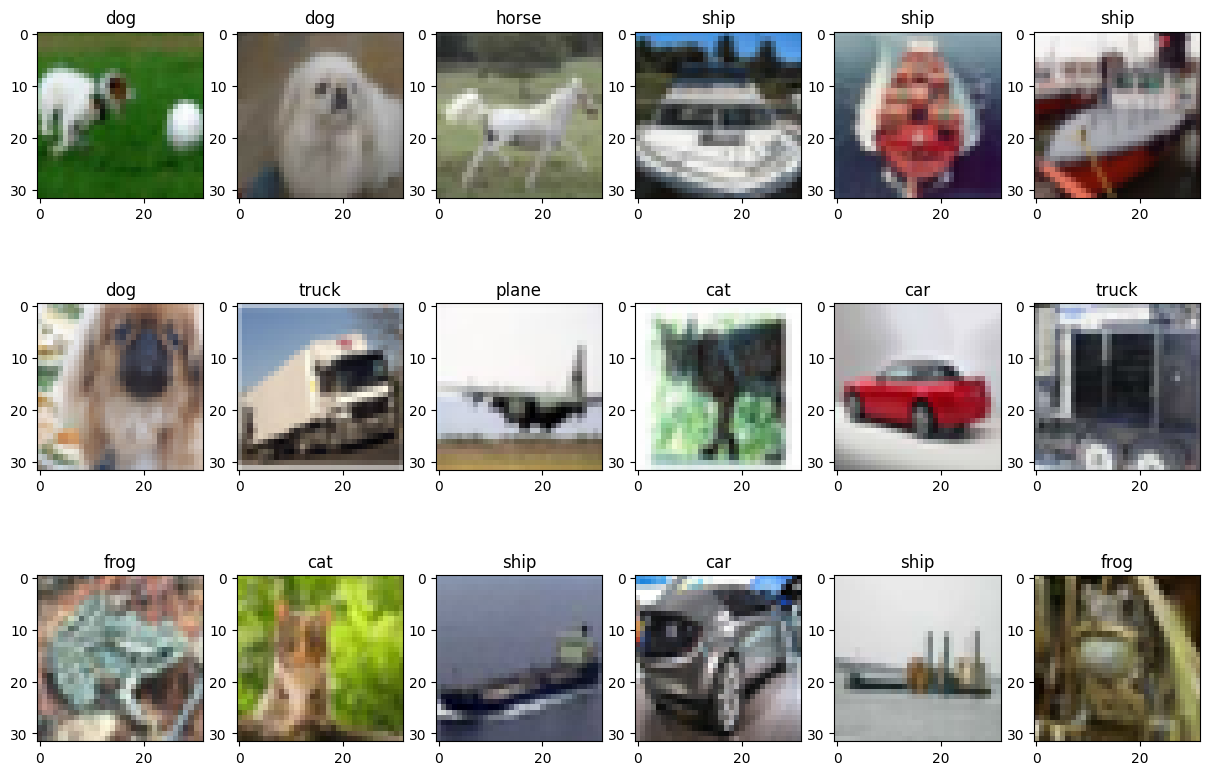

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

num_classes = len(classes)
size = x_train.shape[1]

for ii in range(18):
    plt.subplot(3,6,ii+1)
    idx = np.random.randint(0, len(x_train))
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx])])

Compute the class histogram

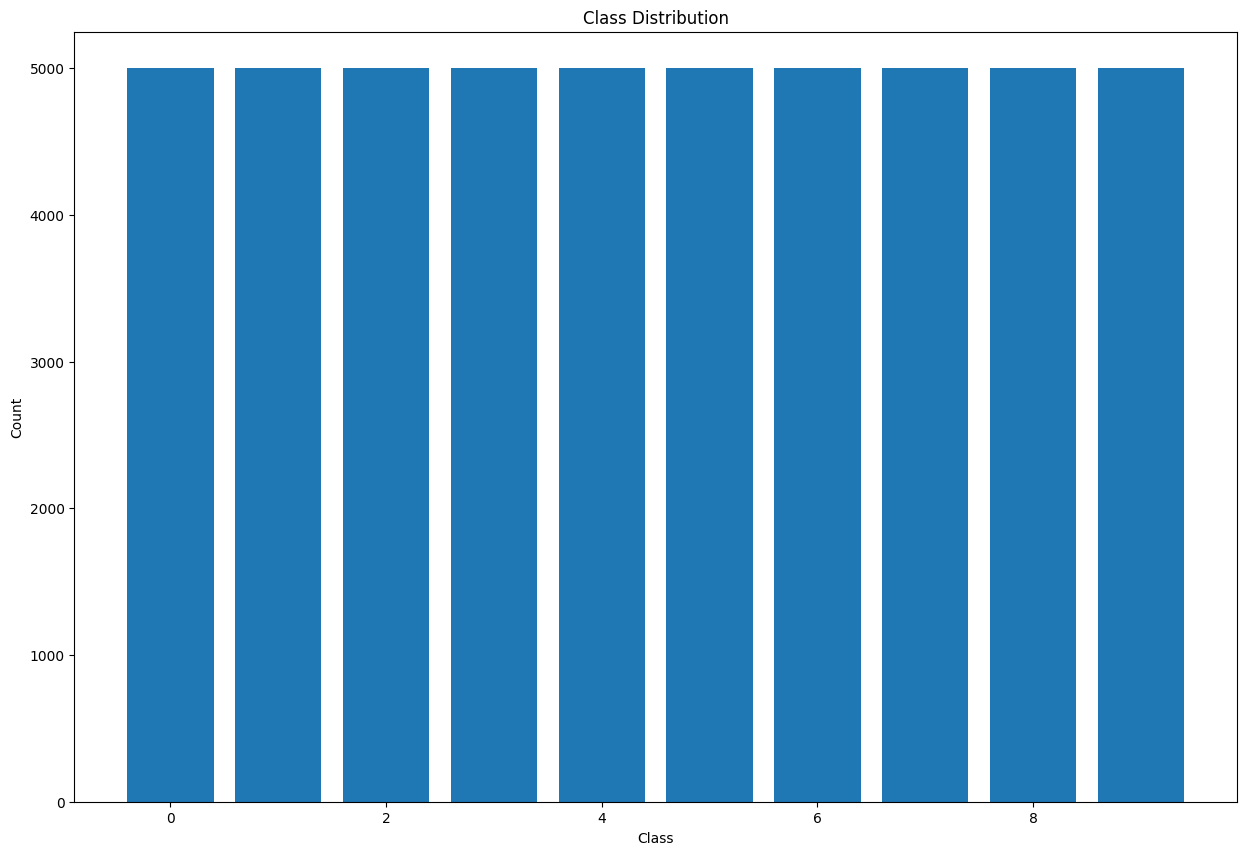

In [7]:
from collections import Counter

hist = Counter(y_train.flatten())

plt.bar(hist.keys(), hist.values())
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

Да, датасет сбалансированный

### Step 1: Data Preparation

In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


### Step 2: Building the Classifier

In [9]:
inputs = Input(shape=(size,size,3))
net = Conv2D(32, kernel_size=(3,3), activation='relu')(inputs)
net = MaxPooling2D(pool_size=(2,2))(net)
net = Conv2D(64, kernel_size=(3,3), activation='relu')(net)
net = MaxPooling2D(pool_size=(2,2))(net)
net = Flatten()(net)
outputs = Dense(num_classes, activation='softmax')(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Training

Compile the model and train it.

In [10]:
epochs = 25
batch_size = 128

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
start = time()
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 48s 133ms/step - accuracy: 0.4164 - loss: 1.6430 - val_accuracy: 0.4906 - val_loss: 1.4716
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 47s 133ms/step - accuracy: 0.5415 - loss: 1.3068 - val_accuracy: 0.5586 - val_loss: 1.2732
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 49s 138ms/step - accuracy: 0.5900 - loss: 1.1831 - val_accuracy: 0.6142 - val_loss: 1.1383
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 86s 149ms/step - accuracy: 0.6199 - loss: 1.0988 - val_accuracy: 0.6374 - val_loss: 1.0757
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 78s 137ms/step - accuracy: 0.6429 - loss: 1.0362 - val_accuracy: 0.6520 - val_loss: 1.0352
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 134ms/step - accuracy: 0.6605 - loss: 0.9867 - val_accuracy: 0.6602 - val_loss: 1.0042
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 51s 144ms/step - accuracy: 0.6752 - loss: 0.9461 - val_accuracy: 0.6708 - val_loss: 0.9773
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 51s 144ms/step - accuracy: 0.6872 - loss: 0

Train Acc      0.7879555821418762
Validation Acc 0.699400007724762


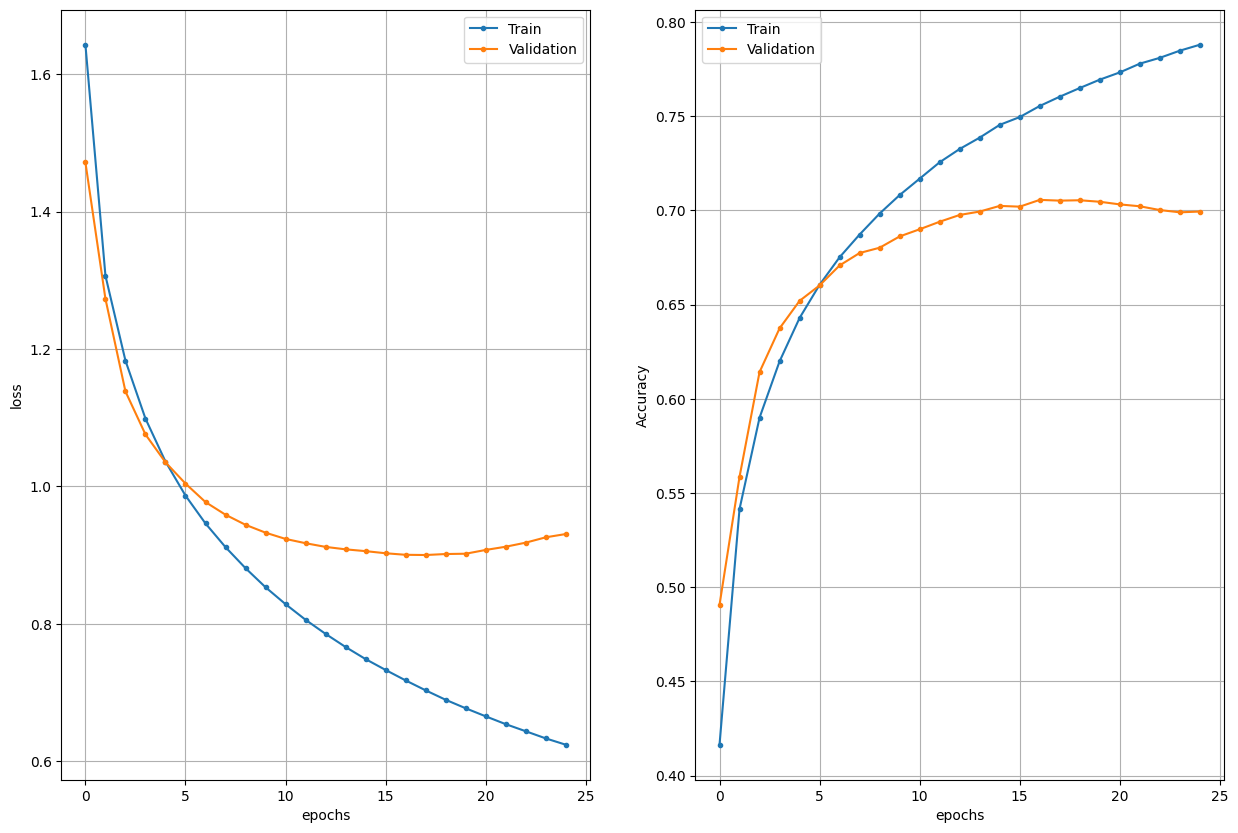

In [11]:
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

### Step 4: Evaluation

In [16]:
y_true = np.argmax(y_test, axis=1)
y_pred = model.predict(x_test)
print('True', y_true[0:5])
print('Pred', np.argmax(y_pred[0:5, :], axis=1))
print('Pred', y_pred[0:5, :])
print(y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
True [3 8 8 0 6]
Pred [3 8 8 0 6]
Pred [[1.47079743e-04 1.36789413e-05 6.16822857e-04 8.69147062e-01
  3.36821261e-03 4.51295786e-02 3.11392099e-02 4.21278994e-04
  4.89636175e-02 1.05336984e-03]
 [1.62873659e-02 4.29779664e-02 6.45072532e-07 1.54816220e-07
  1.64240009e-06 7.53186069e-10 1.62012448e-08 1.03597664e-07
  9.12482977e-01 2.82491855e-02]
 [1.43808588e-01 2.42783681e-01 4.99895425e-04 3.49574164e-03
  1.81129656e-03 1.08161999e-04 4.46151913e-04 4.06963425e-03
  3.55463415e-01 2.47513428e-01]
 [8.55395198e-01 1.56665705e-02 9.96981002e-03 4.93252475e-04
  5.34703843e-02 2.52571863e-05 1.70723462e-04 7.88618985e-04
  6.07761107e-02 3.24403658e-03]
 [6.88503192e-08 1.55759244e-05 2.47318801e-02 2.34522689e-02
  1.70228258e-01 2.65884376e-03 7.78855741e-01 1.98781368e-06
  5.03352567e-05 5.07472396e-06]]
(10000, 10)


In [19]:
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred, axis=1)

for class_id, class_name in classes.items():

    mask = (y_true == class_id)
    acc = (y_pred[mask] == y_true[mask]).mean()

    print(class_name, acc)

plane 0.724
car 0.757
bird 0.445
cat 0.478
deer 0.792
dog 0.639
frog 0.776
horse 0.723
ship 0.751
truck 0.818


In [20]:
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6903 - loss: 0.9682
Test loss   0.9681671857833862
Test metric 0.6902999877929688


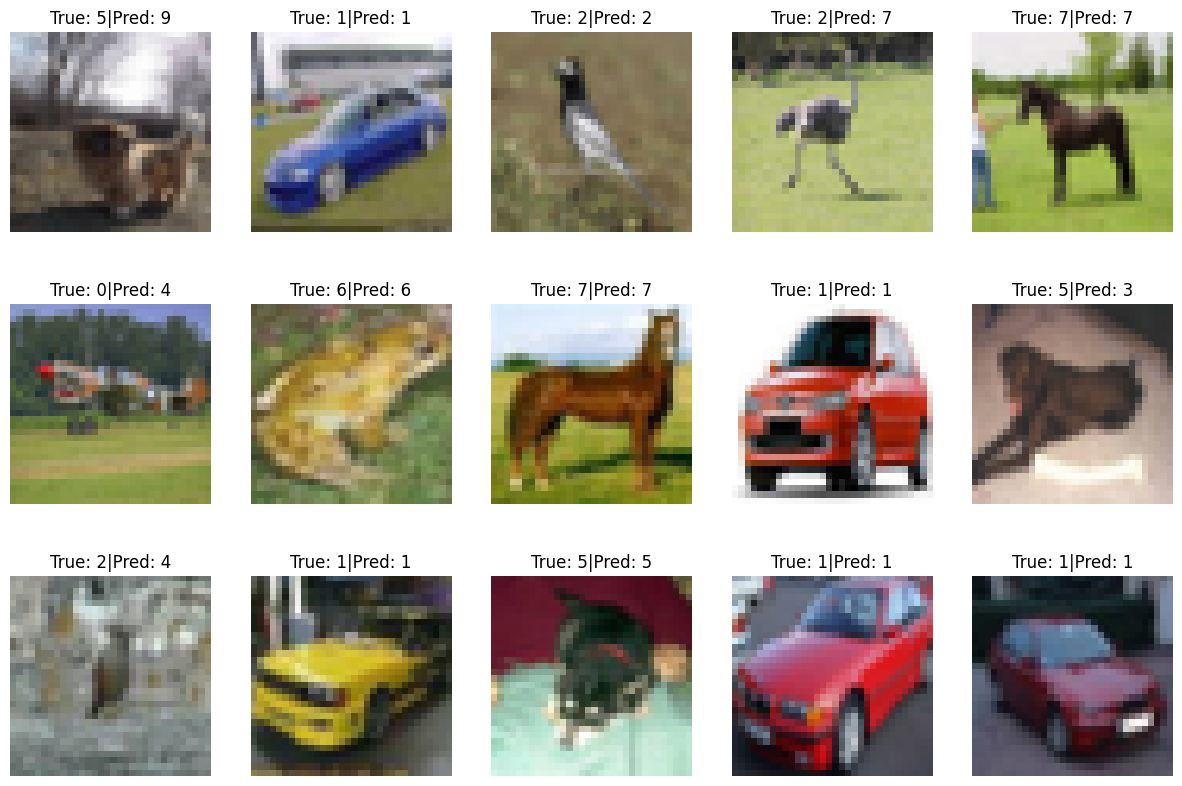

In [21]:
for ii in range(15):
    idx = np.random.randint(0, len(y_pred))
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(y_true[idx]) + '|Pred: ' + str(int(y_pred[idx])))
    plt.axis('off')

### Questions
* What is the overall accuracy of the classifier? 69%

* What modifications would you do in order to improve the classification accuracy?

The model struggles with more complex classes such as cats and birds. To improve performance, we can increase model complexity, add regularization (Dropout), and train longer.

I added an additional convolutional layer and Dropout to reduce overfitting.

In [23]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

inputs = Input(shape=(32,32,3))
net = Conv2D(32, kernel_size=(3,3), activation='relu')(inputs)
net = MaxPooling2D(pool_size=(2,2))(net)
net = Conv2D(64, kernel_size=(3,3), activation='relu')(net)
net = MaxPooling2D(pool_size=(2,2))(net)
net = Conv2D(128, kernel_size=(3,3), activation='relu')(net)
net = MaxPooling2D(pool_size=(2,2))(net)
net = Flatten()(net)
net = Dropout(0.5)(net)
outputs = Dense(num_classes, activation='softmax')(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,378 (384.29 KB)

 Trainable params: 98,378 (384.29 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(x_train, y_train, batch_size=128, epochs=30, validation_split=0.1)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 55s 152ms/step - accuracy: 0.6062 - loss: 1.1176 - val_accuracy: 0.6366 - val_loss: 1.0347
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - accuracy: 0.6197 - loss: 1.0749 - val_accuracy: 0.6626 - val_loss: 0.9770
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 154ms/step - accuracy: 0.6286 - loss: 1.0471 - val_accuracy: 0.6768 - val_loss: 0.9456
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - accuracy: 0.6438 - loss: 1.0185 - val_accuracy: 0.6844 - val_loss: 0.9120
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 53s 151ms/step - accuracy: 0.6532 - loss: 0.9867 - val_accuracy: 0.6966 - val_loss: 0.9020
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 83s 154ms/step - accuracy: 0.6617 - loss: 0.9649 - val_accuracy: 0.6970 - val_loss: 0.8698
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 53s 151ms/step - accuracy: 0.6728 - loss: 0.9382 - val_accuracy: 0.7074 - val_loss: 0.8476
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 53s 152ms/step - accuracy: 0.6764 - loss: 0

Train Acc      0.7585111260414124
Validation Acc 0.7563999891281128


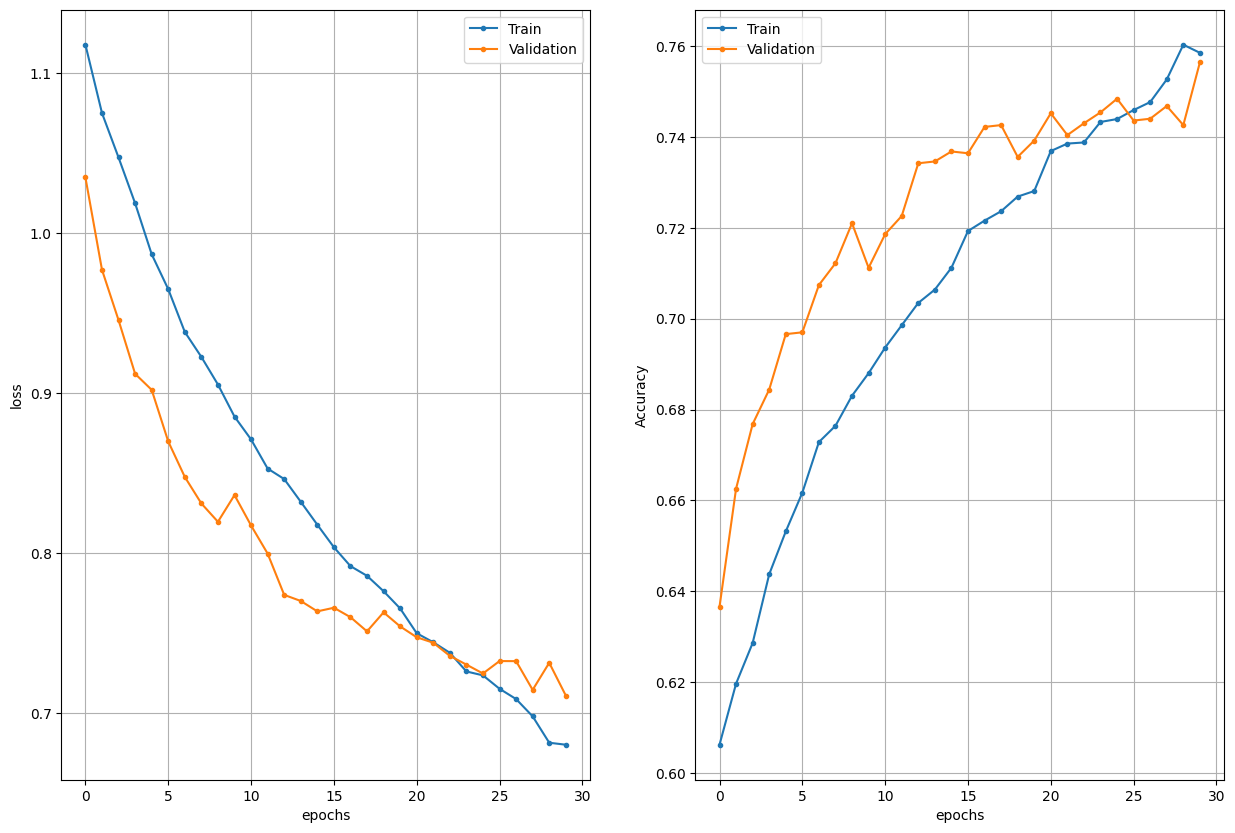

In [26]:
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

In [33]:
y_true = np.argmax(y_test, axis=1)
y_pred = model.predict(x_test)
print('True', y_true[0:5])
print('Pred', np.argmax(y_pred[0:5, :], axis=1))
print('Pred', y_pred[0:5, :])
print(y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
True [3 8 8 0 6]
Pred [3 8 8 0 6]
Pred [[3.6153896e-04 1.3751797e-03 4.6989002e-04 8.8822794e-01 1.1329940e-03
  3.5528097e-02 2.0632418e-03 5.3661125e-04 6.9995895e-02 3.0857633e-04]
 [1.0053852e-02 9.4323389e-02 8.7317879e-08 4.4144142e-09 1.3319130e-08
  2.9922703e-11 2.9339386e-09 7.6313045e-10 8.9509845e-01 5.2408897e-04]
 [7.9346141e-03 9.6778072e-02 7.9119120e-05 1.6189970e-04 1.1205024e-04
  4.9257651e-06 5.6231074e-05 1.7868178e-05 8.7436271e-01 2.0492436e-02]
 [4.3369284e-01 1.8626694e-01 7.6509360e-04 2.0872738e-04 1.1764620e-04
  6.5675185e-06 5.4586428e-04 2.6913218e-05 3.7579915e-01 2.5701944e-03]
 [9.5334235e-07 5.7835737e-06 2.7361339e-02 4.2263791e-02 1.3602217e-01
  7.6871907e-04 7.9348969e-01 2.8662364e-05 5.3510768e-05 5.3632439e-06]]
(10000, 10)


In [34]:
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred, axis=1)

for class_id, class_name in classes.items():

    mask = (y_true == class_id)
    acc = (y_pred[mask] == y_true[mask]).mean()

    print(class_name, acc)

plane 0.809
car 0.863
bird 0.638
cat 0.605
deer 0.656
dog 0.619
frog 0.803
horse 0.773
ship 0.859
truck 0.831


In [35]:
ev = model.evaluate(x_test, y_test)
print('Test loss  ', ev[0])
print('Test metric', ev[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7456 - loss: 0.7454
Test loss   0.745426595211029
Test metric 0.7455999851226807


Overall accuracy 74%